# Завдання
## 1. Отримати вхідні дані із властивостями, заданими в ev_df: реальні та / або синтетичні;
## 2. Провести дослідження вхідних даних та за наявності аномалій застосувати алгоритми їх компенсації.
## 3. Реалізувати рекурентне згладжування вхідних даних з використанням алгоритмів фільтрації Калмана (alfa-beta, alfa-beta-gamma фільтри).
## 4. Фільтр має давати незміщену оцінку.
## 5. Вибір фільтра обгрунтувати.
## 6. Модифікувати скалярний фільтр, що залучений для реалізації функціоналу ЛР1у одному з напрямків: адаптація
## параметрів / «пам’яті» фільтра для усунення ефекту розходження; підвищити ступінь фільтра для подолання ефекту
розходження; розробити алгоритм адаптивної модифікації рекурентного фільтра для подолання ефекту розходження. УВАГА! Рішення у емпірично підібраних константах в параметрах фільтрів лише для конкретної структури вхідних даних не вважається ефективним.

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from datetime import datetime
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)

# Load file

In [2]:

def load_and_clean(path='data/ev_cars.xlsx', column_names=None):
    if column_names is None:
        column_names = ['manufacturer', 'model', 'year', 'price', 'km_age', 'date_added']
    df = pd.read_excel(path, names=None)
    # ensure required cols exist (try to coerce)
    df = df.rename(columns={c: c.strip() for c in df.columns})
    # keep only relevant columns if present
    for c in column_names:
        if c not in df.columns:
            raise ValueError(f"Missing column {c} in input file")
    df = df[column_names].copy()

    # types
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

    # price cleanup
    df['price'] = df['price'].astype(str).str.replace('[$, ]', '', regex=True)
    df['price'] = df['price'].str.replace('\xa0', '', regex=False)
    df['price'] = df['price'].str.replace(' ', '', regex=False)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['km_age'] = pd.to_numeric(df['km_age'], errors='coerce')
    df['vehicle_age'] = datetime.today().year - df['year']

    # drop rows with no date or no price
    df = df.dropna(subset=['date_added', 'price'])
    df = df.reset_index(drop=True)
    return df


# path to xlsx
path = 'data/ev_cars.xlsx'
ev_df = load_and_clean(path)

# 1. Anomaly detection & compensation
#    - univariate IQR outliers + z-score
#    - local interpolation to replace anomalies

In [3]:
def detect_univariate_anomalies(series, method='iqr', k=1.5, z_thresh=4.0):
    """
    Returns boolean mask: True = good, False = anomaly
    method: 'iqr' uses rolling IQR for non-stationary; fallback global
    Also flags extreme z-scores
    """
    s = series.copy()
    mask = pd.Series(True, index=s.index)
    # handle NaNs as not anomalies (they are missing)
    notna = s.dropna()
    if len(notna) < 10:
        return mask  # not enough data to detect
    try:
        # rolling IQR (window 31 days)
        rolling_q1 = s.rolling(window=31, center=True, min_periods=3).quantile(0.25)
        rolling_q3 = s.rolling(window=31, center=True, min_periods=3).quantile(0.75)
        iqr = rolling_q3 - rolling_q1
        low = rolling_q1 - k * iqr
        high = rolling_q3 + k * iqr
        # where rolling values exist
        local_mask = ~((s < low) | (s > high))
        mask = mask & local_mask.fillna(True)
    except Exception:
        # fallback global IQR
        q1 = notna.quantile(0.25);
        q3 = notna.quantile(0.75)
        iqr = q3 - q1
        low = q1 - k * iqr;
        high = q3 + k * iqr
        mask = mask & (~((s < low) | (s > high)))

    # z-score check on detrended residuals
    z = (s - notna.mean()) / notna.std()
    mask = mask & (z.abs() < z_thresh)
    return mask.fillna(True)


def compensate_anomalies(series, mask, method='interpolate'):
    """
    Replace anomalies (mask==False) by interpolation or local median.
    """
    s = series.copy()
    anomalies = ~mask
    if anomalies.sum() == 0:
        return s
    if method == 'interpolate':
        # linear interpolation then forward/back fill
        s_interp = s.copy()
        s_interp[anomalies] = np.nan
        s_interp = s_interp.interpolate(method='time', limit=14)
        s_interp = s_interp.fillna(method='bfill').fillna(method='ffill')
        return s_interp
    elif method == 'local_median':
        s2 = s.copy()
        for idx in s[anomalies].index:
            win = s2[max(s2.index.get_loc(idx) - 7, 0): s2.index.get_loc(idx) + 7]
            s2.loc[idx] = win.median()
        return s2
    else:
        return s

# 2. Filters implementations (scalar measurements)
#    We assume measured quantity z_t (e.g., daily median price).
#    dt=1 (one time step) is default because series is regularly spaced.

In [4]:
def alpha_beta_filter(z, alpha=0.85, beta=0.005, dt=1.0, x0=None, v0=None):
    """
    Alpha-Beta filter (constant velocity model).
    Input:
      z : 1D array or pd.Series of measurements (NaN allowed)
    Returns:
      x_est, v_est, innovations (z - x_pred)
    """
    z = np.asarray(z, dtype=float)
    N = len(z)
    x = np.zeros(N)
    v = np.zeros(N)
    innov = np.zeros(N) * np.nan
    # initialize
    if x0 is None:
        # first non-nan measurement
        first_idx = np.where(~np.isnan(z))[0][0]
        x[first_idx] = z[first_idx]
        start = first_idx + 1
    else:
        x[0] = x0;
        v[0] = v0 if v0 is not None else 0.0
        start = 1
    for t in range(start, N):
        # predict
        x_pred = x[t - 1] + v[t - 1] * dt
        v_pred = v[t - 1]
        if np.isnan(z[t]):
            x[t] = x_pred
            v[t] = v_pred
            innov[t] = np.nan
            continue
        # innovation
        resid = z[t] - x_pred
        innov[t] = resid
        # update
        x[t] = x_pred + alpha * resid
        v[t] = v_pred + (beta * resid) / dt
    return x, v, innov


def alpha_beta_gamma_filter(z, alpha=0.9, beta=0.05, gamma=0.01, dt=1.0, x0=None, v0=None, a0=None):
    """
    Alpha-Beta-Gamma filter (constant acceleration model).
    State: x, v, a
    """
    z = np.asarray(z, dtype=float)
    N = len(z)
    x = np.zeros(N)
    v = np.zeros(N)
    a = np.zeros(N)
    innov = np.zeros(N) * np.nan
    # initialize
    if x0 is None:
        first_idx = np.where(~np.isnan(z))[0][0]
        x[first_idx] = z[first_idx]
        start = first_idx + 1
    else:
        x[0] = x0;
        v[0] = v0 if v0 is not None else 0.0;
        a[0] = a0 if a0 is not None else 0.0
        start = 1
    for t in range(start, N):
        # predict
        x_pred = x[t - 1] + v[t - 1] * dt + 0.5 * a[t - 1] * dt * dt
        v_pred = v[t - 1] + a[t - 1] * dt
        a_pred = a[t - 1]
        if np.isnan(z[t]):
            x[t] = x_pred;
            v[t] = v_pred;
            a[t] = a_pred
            continue
        resid = z[t] - x_pred
        innov[t] = resid
        x[t] = x_pred + alpha * resid
        v[t] = v_pred + (beta * resid) / dt
        a[t] = a_pred + (gamma * resid) / (0.5 * dt * dt + 1e-9)
    return x, v, a, innov


def scalar_kalman_filter(z, Q=1.0, R=10.0, x0=None, P0=1.0):
    """
    Scalar linear Kalman filter for state x with process noise Q and measurement noise R.
    Model:
       x_k = x_{k-1} + w_k   (random walk)
       z_k = x_k + v_k       (measure)
    This is simplest scalar KF (no velocity). For more complex models see matrix KF.
    """
    z = np.asarray(z, dtype=float)
    N = len(z)
    x = np.zeros(N)
    P = np.zeros(N)
    innov = np.zeros(N) * np.nan
    K = np.zeros(N) * np.nan
    # initialize
    if x0 is None:
        # first non-nan
        first = np.where(~np.isnan(z))[0][0]
        x[first] = z[first]
        P[first] = P0
        start = first + 1
    else:
        x[0] = x0;
        P[0] = P0;
        start = 1
    for t in range(start, N):
        # predict
        x_pred = x[t - 1]
        P_pred = P[t - 1] + Q
        if np.isnan(z[t]):
            x[t] = x_pred;
            P[t] = P_pred;
            continue
        # update
        Kt = P_pred / (P_pred + R)
        K[t] = Kt
        resid = z[t] - x_pred
        innov[t] = resid
        x[t] = x_pred + Kt * resid
        P[t] = (1 - Kt) * P_pred
    return x, P, innov, K

# 3. Adaptive filter (prevent divergence)
#    Idea: estimate R (measurement variance) and adapt Q (process noise) using
#    sliding window of innovations. If innovation variance >> expected, increase Q.

In [5]:
def adaptive_kalman_filter(z, Q0=1.0, R0=10.0, window=30, q_scale=1.5, minQ=1e-8, maxQ=1e6):
    """
    Adaptive scalar Kalman: update Q adaptively based on recent innovation variance.
    Q_k+1 = clip( gamma * innovation_var - R_estimate, minQ, maxQ )
    where gamma=q_scale (>1) to be conservative.
    """
    z = np.asarray(z, dtype=float)
    N = len(z)
    x = np.zeros(N)
    P = np.zeros(N)
    innov = np.zeros(N) * np.nan
    K = np.zeros(N) * np.nan
    Q = Q0
    R = R0
    # init
    first = np.where(~np.isnan(z))[0][0]
    x[first] = z[first]
    P[first] = 1.0
    start = first + 1
    innovations_window = []
    for t in range(start, N):
        # predict
        x_pred = x[t - 1]
        P_pred = P[t - 1] + Q
        if np.isnan(z[t]):
            x[t] = x_pred;
            P[t] = P_pred;
            continue
        # update
        Kt = P_pred / (P_pred + R)
        resid = z[t] - x_pred
        innov[t] = resid
        K[t] = Kt
        x[t] = x_pred + Kt * resid
        P[t] = (1 - Kt) * P_pred
        # update innovation window
        innovations_window.append(resid)
        if len(innovations_window) > window:
            innovations_window.pop(0)
        if len(innovations_window) >= max(5, int(window / 4)):
            innov_var = np.var(innovations_window, ddof=1)
            # adaptive rule: set Q such that predicted innovation variance = innov_var.
            # innovation variance approx = P_pred + R  (for scalar random walk + measurement)
            # We update Q conservatively:
            desired = max(innov_var - R, minQ)
            Q_new = np.clip(q_scale * desired, minQ, maxQ)
            # smooth Q update
            Q = 0.9 * Q + 0.1 * Q_new
    return x, P, innov, K, Q

# 4. Diagnostics & evaluation

In [6]:
def evaluate_filter(z, x_est, innov):
    """
    Compute RMSE (on non-nan measurements) and bias (mean innovation).
    Also perform simple z-test for zero-mean innovation.
    """
    z = np.asarray(z, dtype=float)
    mask = ~np.isnan(z)
    rmse = np.sqrt(mean_squared_error(z[mask], x_est[mask]))
    # bias: mean of innovations excluding NaNs
    innov_nonan = np.asarray(innov)[~np.isnan(innov)]
    bias = np.nanmean(innov_nonan) if innov_nonan.size > 0 else np.nan
    # t-test for mean==0
    tstat, pval = (np.nan, np.nan)
    if innov_nonan.size >= 5:
        tstat, pval = stats.ttest_1samp(innov_nonan, 0.0, nan_policy='omit')
    return {'rmse': rmse, 'bias': bias, 'tstat': tstat, 'pval': pval, 'n_innov': innov_nonan.size}

# Main

[pipeline] source=real, length=83, NaNs=21
Evaluation (RMSE, bias, pval) for filters:
Alpha-Beta: {'rmse': 851.1697694075856, 'bias': -7.336071377529772, 'tstat': -0.011565099263793469, 'pval': 0.9908010291115754, 'n_innov': 82}
Alpha-Beta-Gamma: {'rmse': 605.4721347903784, 'bias': -46.692686987855154, 'tstat': -0.06898868299208896, 'pval': 0.9451686548749064, 'n_innov': 82}
Scalar Kalman: {'rmse': 3127.6650157564013, 'bias': -234.34383861422154, 'tstat': -0.41129922022371335, 'pval': 0.6819393550924193, 'n_innov': 82}
Adaptive Kalman: {'rmse': 1659.5213880208087, 'bias': -536.5458137182245, 'tstat': -0.7517178921428332, 'pval': 0.4543994431464682, 'n_innov': 82} final Q: 999667.0436624322


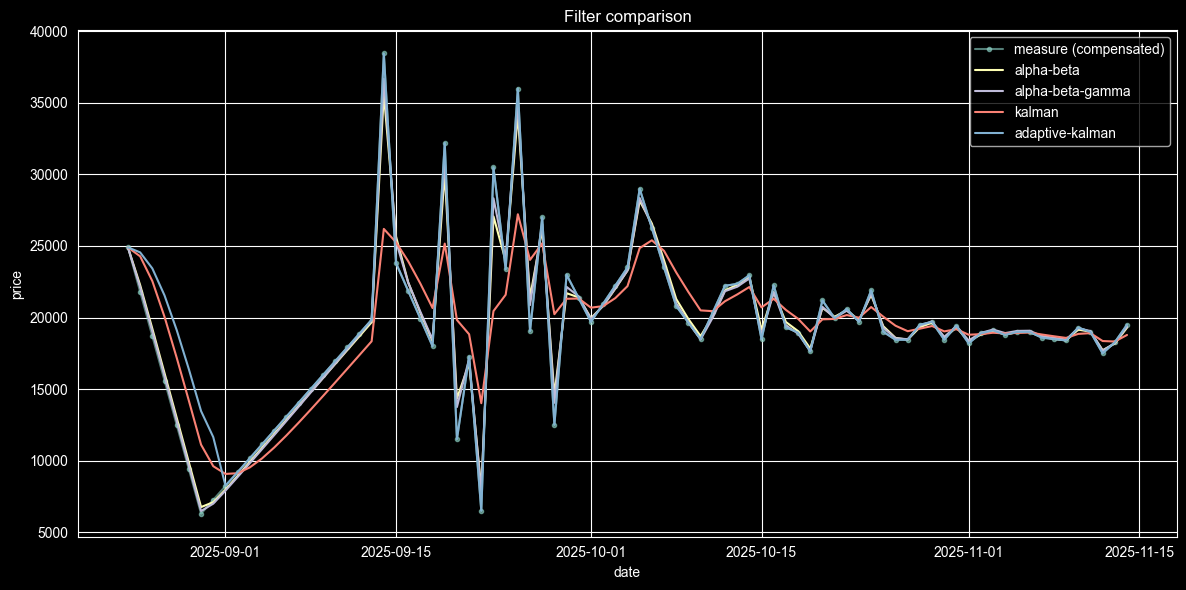

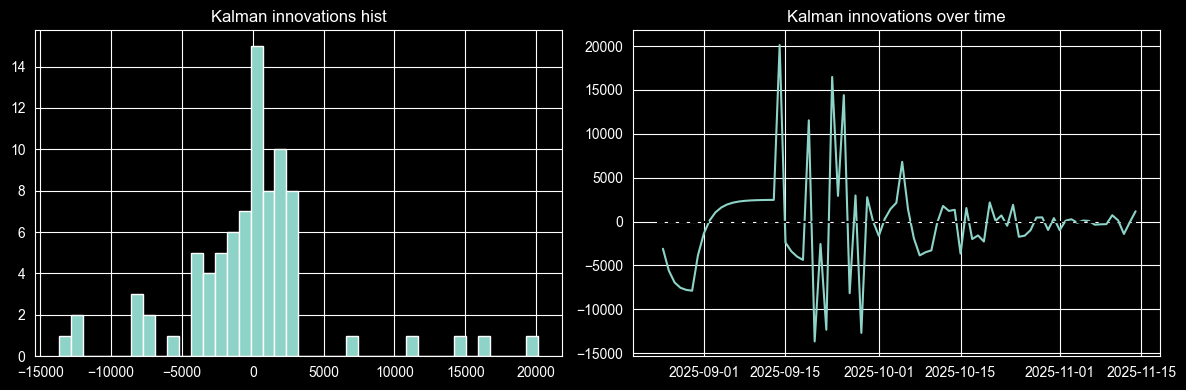

In [7]:
def to_time_series(df, value_col='price', date_col='date_added', freq='D', agg='median'):
    """
    Build regular time series (indexed by date) from ev_df.
    Returns pd.Series indexed by date of aggregated values (NaNs allowed).
    """
    s = df.set_index(pd.to_datetime(df[date_col]))[value_col]
    s = s.resample(freq).agg(agg)
    return s


def main(ev_df, value_col='price', date_col='date_added', freq='D', synth=False):
    """
    End-to-end example:
      - build series (median per day)
      - detect anomalies and compensate
      - apply filters
      - evaluate and plot
    if projected needed(not real) data then we can use flag synth=True.
    """
    if synth:
        # generate synthetic decreasing price series with noise and occasional outliers
        days = 365
        idx = pd.date_range(end=pd.Timestamp.today(), periods=days, freq=freq)
        true = 40000 * (1 + np.linspace(0, 1, days)) ** (-0.5) * np.exp(-0.002 * np.arange(days)) + 500
        meas = true + np.random.normal(scale=800, size=days)
        # inject outliers
        for i in range(10):
            meas[np.random.randint(0, days)] *= (1 + np.random.choice([2.5, -0.6]))
        series = pd.Series(meas, index=idx)
        source = 'synthetic'
    else:
        series = to_time_series(ev_df, value_col=value_col, date_col=date_col, freq=freq, agg='median')
        source = 'real'
        # if too many NaNs, consider forward/back fill briefly before anomaly detection
    print(f"[pipeline] source={source}, length={len(series)}, NaNs={series.isna().sum()}")

    # detect anomalies
    mask = detect_univariate_anomalies(series)
    series_comp = compensate_anomalies(series, mask, method='interpolate')

    # apply filters
    z = series_comp.values
    x_ab, v_ab, innov_ab = alpha_beta_filter(z, alpha=0.85, beta=0.03)
    x_abg, v_abg, a_abg, innov_abg = alpha_beta_gamma_filter(z, alpha=0.9, beta=0.05, gamma=0.01)
    x_kf, P_kf, innov_kf, K_kf = scalar_kalman_filter(z, Q=200.0, R=800.0)
    x_ad, P_ad, innov_ad, K_ad, Q_final = adaptive_kalman_filter(z, Q0=100.0, R0=800.0, window=30)

    # evaluation
    eval_ab = evaluate_filter(z, x_ab, innov_ab)
    eval_abg = evaluate_filter(z, x_abg, innov_abg)
    eval_kf = evaluate_filter(z, x_kf, innov_kf)
    eval_ad = evaluate_filter(z, x_ad, innov_ad)

    print("Evaluation (RMSE, bias, pval) for filters:")
    print("Alpha-Beta:", eval_ab)
    print("Alpha-Beta-Gamma:", eval_abg)
    print("Scalar Kalman:", eval_kf)
    print("Adaptive Kalman:", eval_ad, "final Q:", Q_final)

    # plots
    t = series_comp.index
    plt.figure(figsize=(12, 6))
    plt.plot(t, series_comp, marker='.', linestyle='-', alpha=0.6, label='measure (compensated)')
    plt.plot(t, x_ab, label='alpha-beta')
    plt.plot(t, x_abg, label='alpha-beta-gamma')
    plt.plot(t, x_kf, label='kalman')
    plt.plot(t, x_ad, label='adaptive-kalman')
    plt.legend();
    plt.title('Filter comparison');
    plt.xlabel('date');
    plt.ylabel(value_col)
    plt.tight_layout();
    plt.show()

    # innovations histogram and bias check
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(innov_kf[~np.isnan(innov_kf)], bins=40)
    plt.title('Kalman innovations hist')
    plt.subplot(1, 2, 2)
    plt.plot(t, innov_kf, label='kalman innovation')
    plt.hlines(0, t[0], t[-1], colors='k', linestyles='--')
    plt.title('Kalman innovations over time')
    plt.tight_layout();
    plt.show()

    return {
        'series_raw': series,
        'series_compensated': series_comp,
        'filters': {
            'alpha_beta': {'x': x_ab, 'innov': innov_ab, 'eval': eval_ab},
            'alpha_beta_gamma': {'x': x_abg, 'innov': innov_abg, 'eval': eval_abg},
            'kalman': {'x': x_kf, 'innov': innov_kf, 'eval': eval_kf},
            'adaptive_kalman': {'x': x_ad, 'innov': innov_ad, 'eval': eval_ad, 'Q_final': Q_final}
        }
    }


try:
    # ev_df must be available in the namespace
    res = main(ev_df, value_col='price', date_col='date_added', freq='D', synth=False)
except Exception as e:
    print("If ev_df isn't available or has too few points, running synthetic demo. Error:", e)
    res = main(None, synth=True)
